In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.cross_decomposition import PLSRegression

from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore') 

sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = ['Arial']

Data Matrix Assembly

In [3]:
# 1. Load Data
df_ciber = pd.read_csv("CIBERSORT_Results_Filtered.csv")
if df_ciber.columns[0] == "" or "Unnamed" in df_ciber.columns[0]:
    df_ciber.rename(columns={df_ciber.columns[0]: "Sample_ID"}, inplace=True)

# Replace with your actual scores file
# df_scores = pd.read_csv("Immune_Microenvironment_Scores.csv") 
# df_merged = pd.merge(df_ciber, df_scores, on="Sample_ID")

# For testing right now, assuming df_merged is just df_ciber
df_merged = df_ciber.copy() 

# 2. Assign Labels
high_cp = ["GSM7024387", "GSM7024389", "GSM7024391", "GSM7024392", "GSM7024394", "GSM7024396", "GSM7024398", "GSM7024404", "GSM7024407", "GSM7024413", "GSM7024414", "GSM7024422", "GSM7024385", "GSM7024400", "GSM7024420", "GSM7024409", "GSM7024405"]
low_cp = ["GSM7024418", "GSM7024402", "GSM7024424", "GSM7024411", "GSM7024416"]

df_merged['Group'] = df_merged['Sample_ID'].apply(lambda x: 1 if x in high_cp else (0 if x in low_cp else np.nan))
df_clean = df_merged.dropna(subset=['Group']).copy()

# 3. Feature Matrix Extraction
# Adjust column indices based on your merged dataframe structure
X = df_clean.drop(columns=['Sample_ID', 'Group', 'P-value', 'Correlation', 'RMSE'], errors='ignore')
y = df_clean['Group'].astype(int).values

X_scaled = StandardScaler().fit_transform(X)

print(f"Matrix Ready: {X.shape[0]} samples, {X.shape[1]} features.")
print(f"Class Distribution: High_CP(1)={np.sum(y==1)}, Low_CP(0)={np.sum(y==0)}")

Matrix Ready: 15 samples, 22 features.
Class Distribution: High_CP(1)=12, Low_CP(0)=3


Parallel Model Benchmarking (LOO-CV)

In [5]:
loo = LeaveOneOut()

# Configure algorithms with extreme small-sample constraints
models = {
    "LASSO": LogisticRegression(penalty='l1', solver='liblinear', C=0.5, class_weight='balanced', random_state=42),
    "ElasticNet": LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, C=0.5, class_weight='balanced', max_iter=2000, random_state=42),
    "Ridge": RidgeClassifier(alpha=1.0, class_weight='balanced', random_state=42),
    "Linear SVM": SVC(kernel='linear', C=0.1, class_weight='balanced', random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, max_depth=2, min_samples_leaf=2, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=2, min_samples_leaf=2, class_weight='balanced', random_state=42),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():
    # Trees and Naive Bayes handle unscaled data better; Linear models require scaling
    X_input = X.values if name in ["Random Forest", "Extra Trees", "Naive Bayes"] else X_scaled
    
    scores = cross_val_score(model, X_input, y, cv=loo, scoring='balanced_accuracy')
    results.append({'Model': name, 'LOO_Balanced_Accuracy': np.mean(scores)})

performance_df = pd.DataFrame(results).sort_values(by='LOO_Balanced_Accuracy', ascending=False)
print("--- Benchmark Results ---")
print(performance_df.to_string(index=False))

--- Benchmark Results ---
        Model  LOO_Balanced_Accuracy
        LASSO               1.000000
   ElasticNet               0.933333
        Ridge               0.933333
   Linear SVM               0.933333
  Extra Trees               0.933333
Random Forest               0.866667
  Naive Bayes               0.800000


Visualization

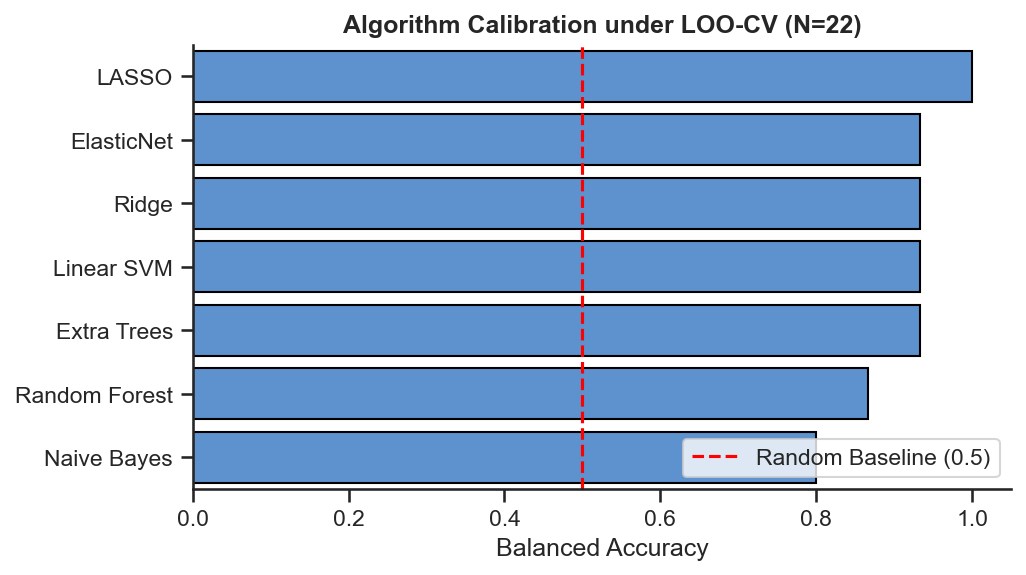

In [6]:
plt.figure(figsize=(7, 4), dpi=150)
ax = sns.barplot(x="LOO_Balanced_Accuracy", y="Model", data=performance_df, color="#4A90E2", edgecolor="black")

plt.axvline(x=0.5, color='red', linestyle='--', label="Random Baseline (0.5)")

plt.title("Algorithm Calibration under LOO-CV (N=22)", fontweight='bold')
plt.xlabel("Balanced Accuracy")
plt.ylabel("")
plt.xlim(0, 1.05)
plt.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

Comprehensive Validation

In [7]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

# 选择冠军模型 LASSO 进行深度剖析
best_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, class_weight='balanced', random_state=42)

# 使用留一法获取每个样本的硬预测类别 (0 或 1)
y_pred = cross_val_predict(best_model, X_scaled, y, cv=loo)

# 使用留一法获取每个样本的预测概率 (属于 High_CP 的概率)
y_prob = cross_val_predict(best_model, X_scaled, y, cv=loo, method='predict_proba')[:, 1]

# 1. 计算全面的分类报告
print("=== LOO-CV 综合分类评价报告 ===")
print(classification_report(y, y_pred, target_names=['Low_CP (0)', 'High_CP (1)']))

# 2. 混淆矩阵
cm = confusion_matrix(y, y_pred)
print("=== 混淆矩阵 ===")
print(f"True Low_CP predicted as Low_CP: {cm[0,0]}")
print(f"True Low_CP predicted as High_CP: {cm[0,1]}")
print(f"True High_CP predicted as Low_CP: {cm[1,0]}")
print(f"True High_CP predicted as High_CP: {cm[1,1]}")

# 3. 计算综合 AUC 
# 注意：在极小样本LOO下，如果全对，AUC就是1.0
auc_score = roc_auc_score(y, y_prob)
print(f"\n=== 全局 ROC-AUC 得分: {auc_score:.4f} ===")

=== LOO-CV 综合分类评价报告 ===
              precision    recall  f1-score   support

  Low_CP (0)       1.00      1.00      1.00         3
 High_CP (1)       1.00      1.00      1.00        12

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

=== 混淆矩阵 ===
True Low_CP predicted as Low_CP: 3
True Low_CP predicted as High_CP: 0
True High_CP predicted as Low_CP: 0
True High_CP predicted as High_CP: 12

=== 全局 ROC-AUC 得分: 1.0000 ===


Feature Prioritization

In [8]:
# 在全量数据上拟合以提取最终特征权重
best_model.fit(X_scaled, y)

# 提取特征与系数
feature_ranking = pd.DataFrame({
    'Feature': X.columns,
    'Weight': best_model.coef_[0]
})

# 计算绝对值用于排序重要性
feature_ranking['Importance'] = feature_ranking['Weight'].abs()

# 过滤掉被 LASSO 剔除的噪音特征 (Weight == 0)
active_features = feature_ranking[feature_ranking['Importance'] > 0].copy()

# 按从正到负排序：
# 正数 (Weight > 0) -> 驱动 High_CP (炎性浸润激活)
# 负数 (Weight < 0) -> 维持 Low_CP (潜伏期抑制屏障)
active_features = active_features.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("=== 微环境重塑核心驱动特征 (LASSO 筛选) ===")
print(active_features[['Feature', 'Weight']])

# 保存以便后续补充材料使用
active_features.to_csv("TME_Feature_Prioritization_LASSO.csv", index=False)

=== 微环境重塑核心驱动特征 (LASSO 筛选) ===
       Feature    Weight
0  Neutrophils -1.467987


In [9]:
from sklearn.linear_model import LogisticRegression

# 使用 ElasticNet，降低 L1 的惩罚比例 (l1_ratio=0.1)，让更多协同细胞显现
en_model = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.1, C=1.0, class_weight='balanced', max_iter=5000, random_state=42)
en_model.fit(X_scaled, y)

en_features = pd.DataFrame({
    'Feature': X.columns,
    'Weight': en_model.coef_[0]
}).sort_values(by='Weight', key=abs, ascending=False)

# 过滤掉极小噪音
en_features = en_features[en_features['Weight'].abs() > 0.05]

print("=== ElasticNet 提取的微环境重塑全景驱动特征 ===")
print(en_features)

=== ElasticNet 提取的微环境重塑全景驱动特征 ===
                         Feature    Weight
21                   Neutrophils -0.635756
20                   Eosinophils -0.539344
19          Mast cells activated -0.495549
17     Dendritic cells activated -0.399094
3                    T cells CD8  0.370266
4              T cells CD4 naive -0.322934
14                Macrophages M1  0.298047
18            Mast cells resting -0.248859
13                Macrophages M0  0.233951
2                   Plasma cells -0.160920
9            T cells gamma delta  0.146877
11            NK cells activated  0.127499
6   T cells CD4 memory activated  0.102575
1                 B cells memory  0.094140
15                Macrophages M2  0.085947
0                  B cells naive  0.071970
5     T cells CD4 memory resting  0.054248


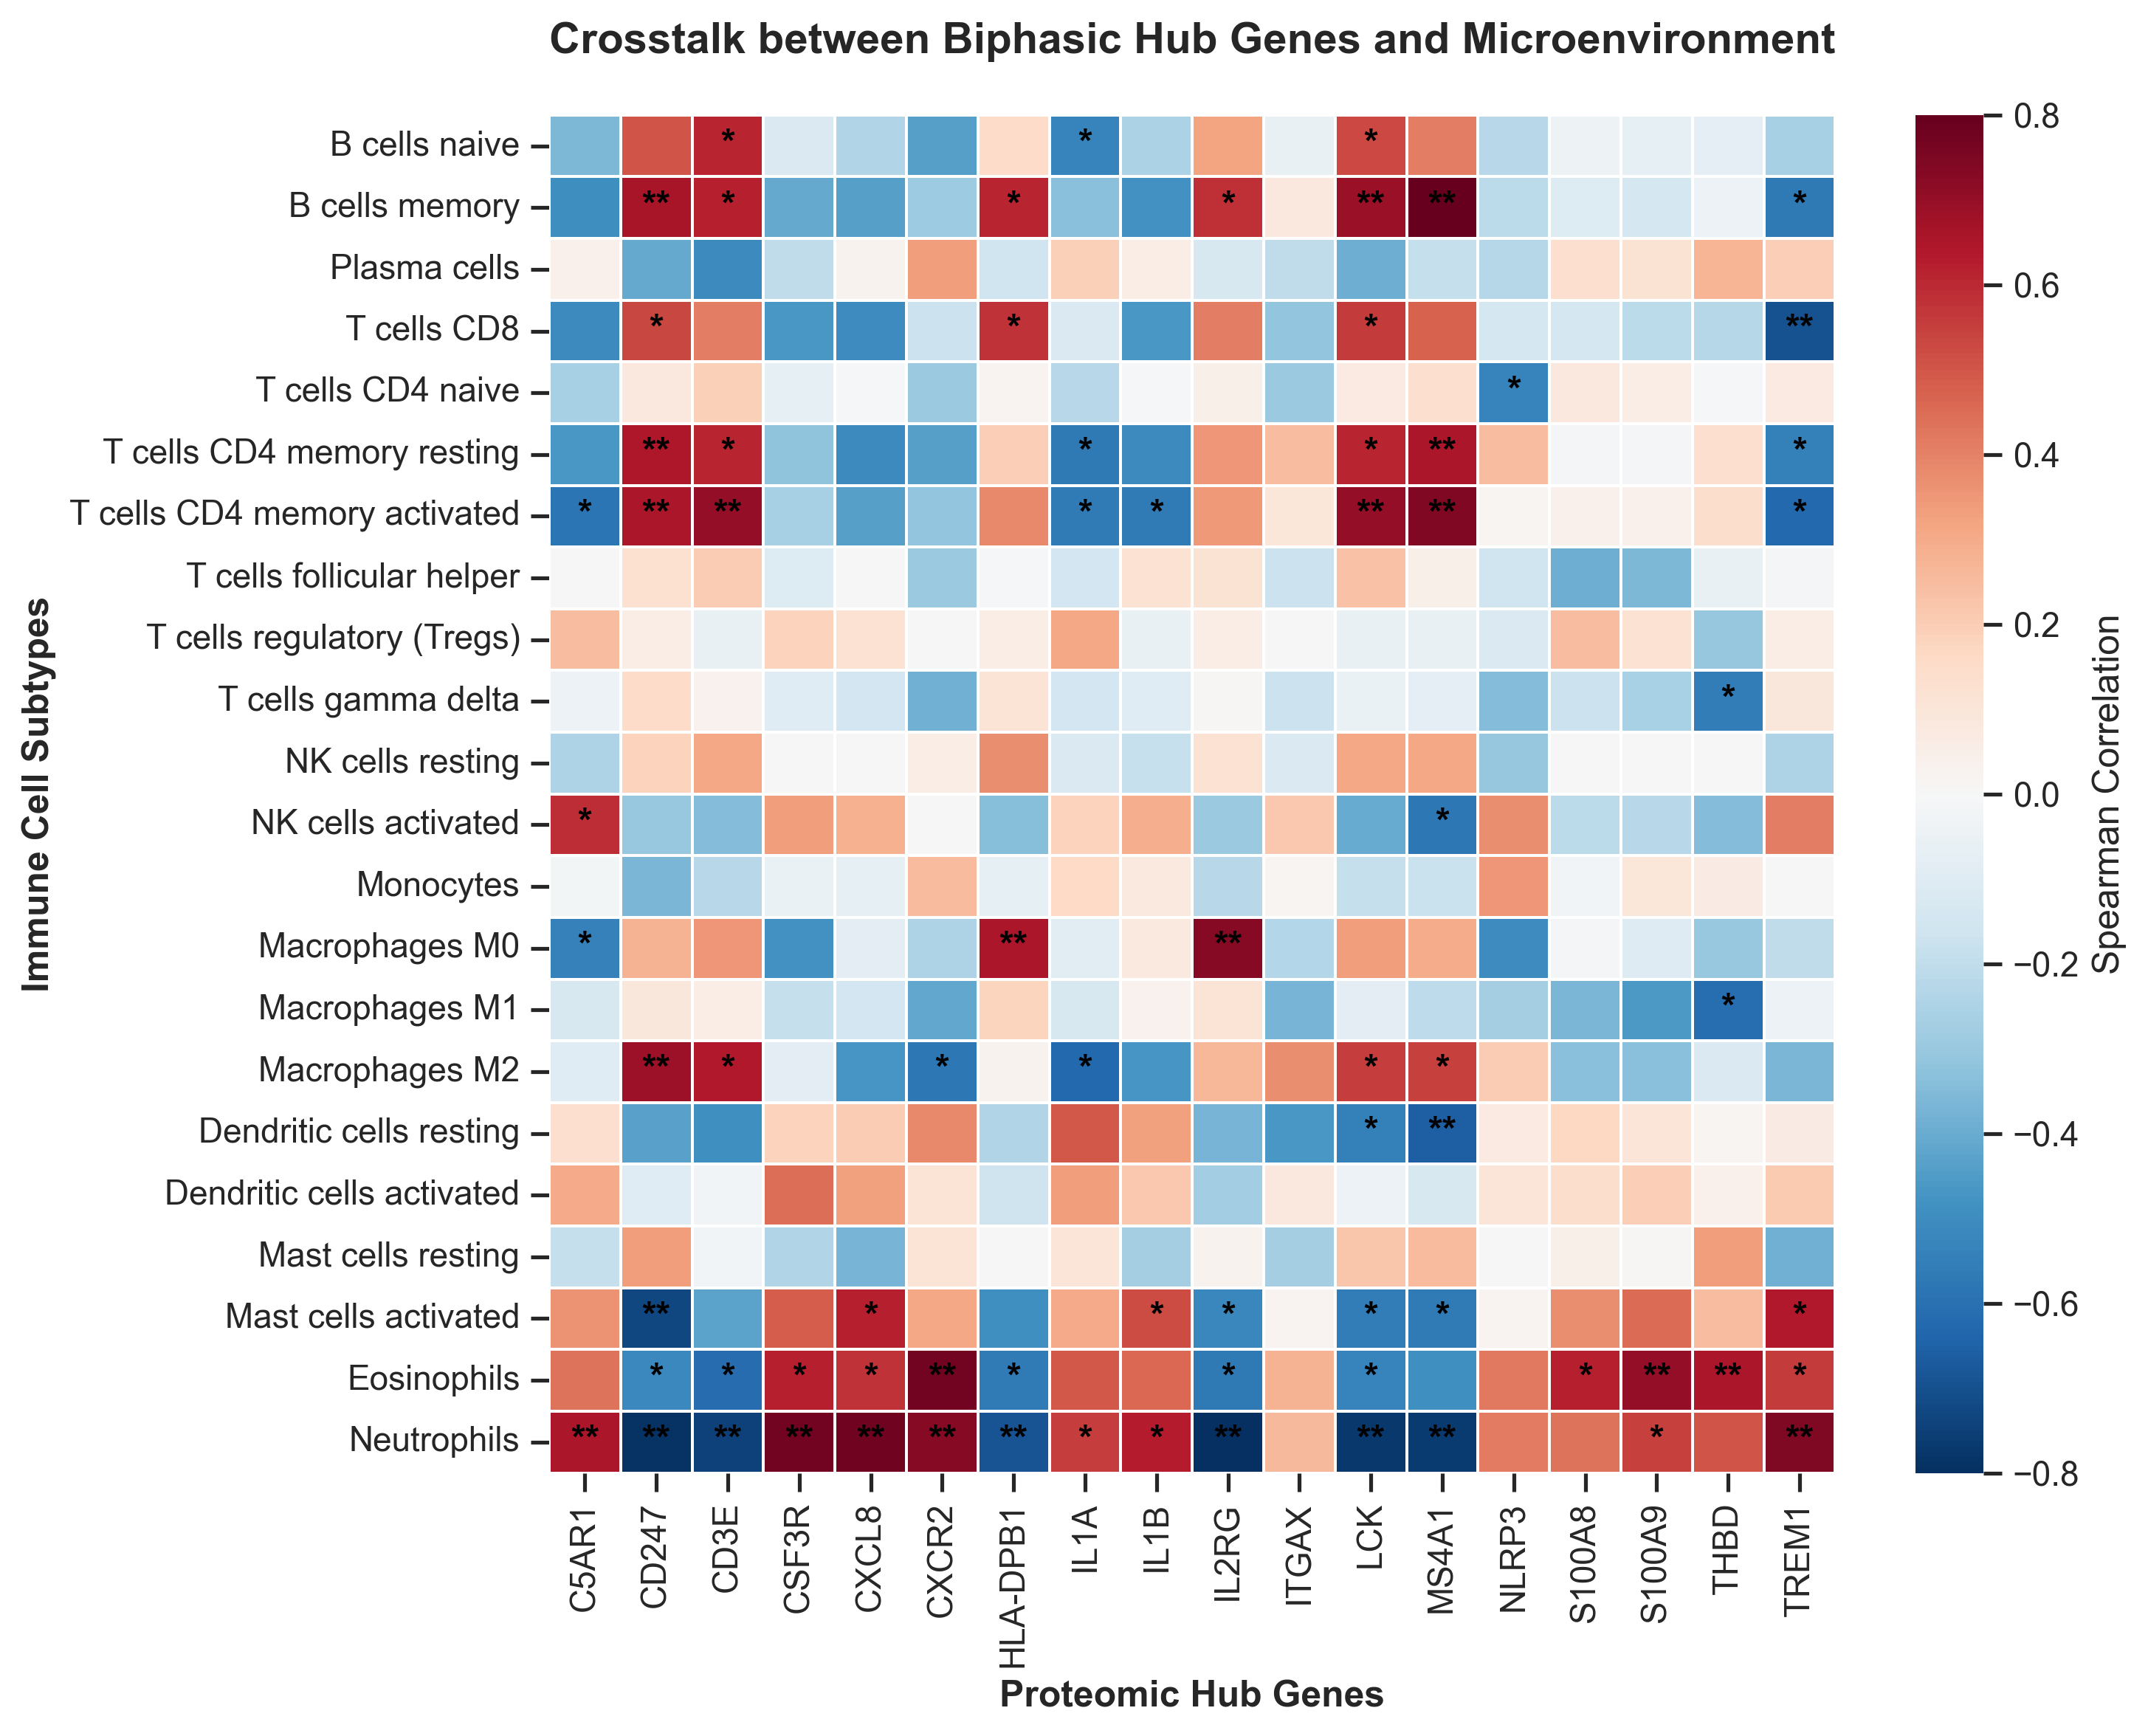

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# 1. 加载数据
# 你的免疫细胞数据
immune_df = df_clean.copy() # 包含 Sample_ID 和 22种细胞比例

# 你的 Hub Genes 表达量数据 (你需要准备这个表)
# 格式: Sample_ID, CXCL8, S100P, FN1, STAT3, ...
genes_df = pd.read_csv("Hub_Genes_Expression.csv") 

# 合并数据
merged_data = pd.merge(immune_df, genes_df, on="Sample_ID")

# 分离免疫特征和基因特征
immune_features = X.columns.tolist() # 从 B cells naive 到 Neutrophils
gene_features = genes_df.columns.drop("Sample_ID").tolist()

# 2. 计算 Spearman 相关性矩阵与 P-value 矩阵
# 在极小样本 (N=22) 中，必须用 Spearman (抗异常值) 而不是 Pearson
corr_matrix = pd.DataFrame(index=immune_features, columns=gene_features)
pval_matrix = pd.DataFrame(index=immune_features, columns=gene_features)

for imm in immune_features:
    for gen in gene_features:
        r, p = spearmanr(merged_data[imm], merged_data[gen])
        corr_matrix.loc[imm, gen] = r
        pval_matrix.loc[imm, gen] = p

# 确保数据格式为 float
corr_matrix = corr_matrix.astype(float)
pval_matrix = pval_matrix.astype(float)

# 3. 绘制 SCI 顶级刊物风格的相关性热图 (带显著性星号)
plt.figure(figsize=(10, 8), dpi=300)

# 绘制底层颜色热图
ax = sns.heatmap(
    corr_matrix, 
    cmap="RdBu_r", # 红蓝渐变 (红=正相关, 蓝=负相关)
    center=0, 
    vmin=-0.8, vmax=0.8,
    linewidths=0.5, 
    linecolor='white',
    cbar_kws={'label': 'Spearman Correlation'}
)

# 动态打上显著性星号 (* p<0.05, ** p<0.01)
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        p_val = pval_matrix.iloc[i, j]
        if p_val < 0.01:
            ax.text(j+0.5, i+0.5, '**', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
        elif p_val < 0.05:
            ax.text(j+0.5, i+0.5, '*', ha='center', va='center', color='black', fontsize=12, fontweight='bold')

plt.title("Crosstalk between Biphasic Hub Genes and Microenvironment", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Immune Cell Subtypes", fontsize=12, fontweight='bold')
plt.xlabel("Proteomic Hub Genes", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("graphs_Gene_Immune_Correlation_Heatmap.png")
plt.show()